# AA_Cam_pose_estimate_batches

Batch harness: send one video's frames through every reconstruction technique (VGGT, VGGT-Omega, MegaSaM, CUT3R, lingbot-map), align each technique's camera trace against a GPS ground-truth trace, and collect RMSE/mean_dist/runtime into one results table instead of separate pairwise chart images (see `AA_CAM_POSE_COMPARE_01.ipynb` for the older pairwise-only version).

Cells reused near-verbatim from `ZZ_MASTER_SWITCH_V03.ipynb`/`AJ_lingbotmap.ipynb` where noted.

In [1]:
%load_ext autoreload
%autoreload 2

## Config

In [11]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Find the repo root by walking up until we hit src/A_Config.py, rather than
# trusting cwd -- VS Code's Jupyter kernel cwd is often the workspace root, not
# this notebook's own folder, and inside the Singularity container cwd is the
# bind-mount root (/workspace) directly, not Experiments/. Both broke
# Path.cwd().parent this session; this walk-up is robust to either.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)

from A_Config import (
    set_case, case_dir, frames_for_recon_dir, lingbot_map_dir,frames_for_cam_poses_dir,
    vggt_o_output_dir, vggt_output_dir, predictions_path, cut3r_output_dir, reg_dir, FRAME_NAME_FMT,asset_name
)

case_name = "11_walk_home_1"
experiment = "batch"
set_case(case_name, experiment)

# One shared frame set used by every technique, so the comparison is apples-to-apples.
# NOTE: CUT3R can't handle big recons (per AJ_lingbotmap.ipynb's own comment) -- keep
# this under ~200 frames if CUT3R is enabled below.
frames_for_recon = case_dir() / "020_frames_for_cam_poses"/"Cam_pose_v01"/"poses_0125"
print("frames_for_recon:", frames_for_recon)

out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

runtimes = {}  # technique -> minutes (decimal), filled in by each runner cell below

FLAGS = {
    "CUT3R_RECON":     True,
    "MEGA_SAM_RECON":  True,
    "VGGT_RECON":      True,
    "VGGT_O_RECON":    True,
    "LINGBOT_MAP_RECON": True,
    "REALITYSCAN_RECON": False,
    "FRAME_SELECTION": True,

}

project_root: /workspace/project
frames_for_recon: /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125


## Ground truth

Manually set for now -- eventually GT files will follow a `{case_name}_{experiment}_lat_lon_gt.csv` convention, but that naming isn't real on disk yet, so this stays an explicit variable rather than guessed automation.

`GPS_tags.csv` format: columns `Frame` (e.g. `"1661.jpg"`), `lat`, `lon` -- sparse, manually curated keyframe-to-GPS anchors, not one row per video frame.

In [3]:
# TODO: once GT files follow the case_experiment_lat_lon_gt.csv convention,
# derive this automatically instead of setting it by hand.
gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"

from Q_GPS_processing import csv_to_GPS_dict
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

101 GT anchors loaded from GPS_tags.csv


FRAMES

In [3]:
#

In [6]:
#FRAME SELECTION - Frame selection to make the cam poses
FRAME_SELECTION = False
if FRAME_SELECTION == True:
    # Parameters
    fps = 30.07
    interval     = 25/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = 15     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json
   

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path()),
        output_dir    = str(frames_for_cam_poses()),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_3D_recon,
        end_frame    = end_3D_recon
    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
    FRAME_SELECTION = False
else:
    print("Cell disabled")

Cell disabled


## CUT3R

In [7]:
if FLAGS["CUT3R_RECON"]:
    from run_models.E_cut3r_recon import run_cut3r

    t0 = time.perf_counter()
    run_cut3r(
        frames_dir=frames_for_recon,
        output_dir=cut3r_output_dir(),
        ckpt_path=project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
        render_3rdperson=False,
    )
    runtimes["CUT3R"] = (time.perf_counter() - t0) / 60  # decimal minutes
else:
    print("Cell disabled")

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Loading model...
... loading model from /workspace/project/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
125 frames  →  /workspace/project/Data/11_walk_home_1/035_CUT3R_output/batch


CUT3R:   0%|          | 0/125 [00:00<?, ?it/s]/workspace/project/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/workspace/project/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|██████████| 125/125 [00:27<00:00,  4.58it/s]

State saved → /workspace/project/Data/11_walk_home_1/035_CUT3R_output/batch/cut3r_state.pt
Done. 125 frames in 0.5 min  (0.22 s/frame)
Output: /workspace/project/Data/11_walk_home_1/035_CUT3R_output/batch


In [8]:
if FLAGS["CUT3R_RECON"]:
    from run_models.E_cut3r_recon import run_cut3r

    t0 = time.perf_counter()
    run_cut3r(
        frames_dir=frames_for_recon,
        output_dir=cut3r_output_dir()/"revisit",
        ckpt_path=project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
        render_3rdperson=False,
        revisit = True
    )
    runtimes["CUT3R_Revisit"] = (time.perf_counter() - t0) / 60  # decimal minutes
else:
    print("Cell disabled")

Loading model...
... loading model from /workspace/project/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
125 frames  →  /workspace/project/Data/11_walk_home_1/035_CUT3R_output/batch/revisit


CUT3R: 100%|██████████| 125/125 [00:17<00:00,  7.14it/s]


Pass 2 (revisiting): re-processing all frames with frozen final state...


revisit: 100%|██████████| 125/125 [00:31<00:00,  3.96it/s]

Revisit pass done. 125 frames in 0.5 min  (0.25 s/frame)
State saved → /workspace/project/Data/11_walk_home_1/035_CUT3R_output/batch/revisit/cut3r_state.pt
Done. 125 frames in 0.8 min  (0.39 s/frame)
Output: /workspace/project/Data/11_walk_home_1/035_CUT3R_output/batch/revisit


## MegaSaM

In [14]:
print(frames_for_recon)

/workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125


In [8]:
if FLAGS["MEGA_SAM_RECON"]:
    from run_models.E_megasam_recon import run_megasam
    from A_Config import asset_name

    megasam_output_dir = case_dir() / "036_MEGASAM_output" / experiment
    megasam_output_dir.mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()
    megasam_npz_path = run_megasam(
        frames_dir=frames_for_recon,
        
        mega_sam_dir=project_root / "Models" / "mega-sam",
        scene_name=asset_name(),
    )
    runtimes["MegaSaM"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

$ conda run --no-capture-output -n mega_sam python Depth-Anything/run_videos.py --encoder vitl --load-from Depth-Anything/checkpoints/depth_anything_vitl14.pth --img-path /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125 --outdir Depth-Anything/video_visualization/11_walk_home_1_batch


Using cache found in /home/vscode/.cache/torch/hub/facebookresearch_dinov2_main


Total parameters: 335.32M


100%|██████████| 125/125 [00:27<00:00,  4.60it/s]


  Depth-Anything done in 37s
$ conda run --no-capture-output -n mega_sam python UniDepth/scripts/demo_mega-sam.py --scene-name 11_walk_home_1_batch --img-path /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125 --outdir UniDepth/outputs
Torch version: 2.0.1


...

################################
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
median_hessian, median_calib  tensor(4960.7695, device='cuda:0') tensor([1.8678e+18], device='cuda:0')
_opt_intr  True  use_mono  False  alpha  0.0
################## KEYFRAME BUNDLE ADJUSTMENT ################################  use_mono  False
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
Global BA Iteration #11
Global BA Iteration #12
Global BA Iteration #13
Global BA Iteration #14
Global BA Iteration #15
Global BA Iteration #16
Global BA Iteration #17
Global BA Iteration #18
Global BA Iteration #19
Global BA Iteration #20

GLOBAL FRAME BA ####

125it [00:03, 34.65it/s]
  0%|          | 0/124 [00:00<?, ?it/s]/workspace/project/.conda_envs/mega_sam/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995026/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 110/110 [00:09<00:00, 12.13it/s]


  RAFT flow done in 60s
$ conda run --no-capture-output -n mega_sam python cvd_opt/cvd_opt.py --scene_name 11_walk_home_1_batch --w_grad 2.0 --w_normal 5.0
CVD optimisation: 11_walk_home_1_batch
step  0 2.493605852127075
step  20 1.7785634994506836
step  40 1.39716637134552
step  60 1.1209510564804077
step  80 1.0162681341171265
step  0 0.9080227613449097
step  20 0.9821769595146179
step  40 0.9103398323059082
step  60 0.8828546404838562
step  80 0.8675005435943604
step  100 0.8567681908607483
step  120 0.8493819236755371
step  140 0.8423881530761719
step  160 0.8366437554359436
step  180 0.8311326503753662
step  200 0.8260048031806946
step  220 0.8223699331283569
step  240 0.8179566860198975
step  260 0.8136464953422546
step  280 0.809846043586731
step  300 0.8061885237693787
step  320 0.8030797839164734
step  340 0.799300491809845
step  360 0.7971819043159485
step  380 0.7947890758514404


/workspace/project/Models/mega-sam/cvd_opt/cvd_opt.py:470: RuntimeWarning: overflow encountered in cast
  depths=np.clip(np.float16(1.0 / disp_data_opt), 1e-3, 1e2),


  CVD optimisation done in 125s
Output: /workspace/project/Data/11_walk_home_1/036_MEGASAM_output/batch/11_walk_home_1_batch_sgd_cvd_hr.npz


## VGGT (plain)

In [10]:
vggt_output_dir = case_dir() / "034_VGGT_output" / experiment

In [18]:
if FLAGS["VGGT_RECON"]:
    import argparse
    sys.path.insert(0, str(project_root / "Models" / "VGGT" / "vggt"))
    from demo_colmap import demo_fn

    vggt_output_dir = case_dir() / "034_VGGT_output" / experiment

    vggt_args = argparse.Namespace(
        scene_dir=str(case_dir()),
        image_dir=str(frames_for_recon),
        output_dir=str(vggt_output_dir),
        max_frames=500,
        load_resolution=518,
        seed=42,
        use_ba=False,
        max_reproj_error=8.0,
        shared_camera=False,
        camera_type="SIMPLE_PINHOLE",
        vis_thresh=0.2,
        query_frame_num=8,
        max_query_pts=4096,
        fine_tracking=True,
        conf_thres_value=5.0,
    )

    t0 = time.perf_counter()
    demo_fn(vggt_args)
    runtimes["VGGT"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Arguments: {'scene_dir': '/workspace/project/Data/11_walk_home_1', 'image_dir': '/workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125', 'output_dir': '/workspace/project/Data/11_walk_home_1/034_VGGT_output/batch', 'max_frames': 500, 'load_resolution': 518, 'seed': 42, 'use_ba': False, 'max_reproj_error': 8.0, 'shared_camera': False, 'camera_type': 'SIMPLE_PINHOLE', 'vis_thresh': 0.2, 'query_frame_num': 8, 'max_query_pts': 4096, 'fine_tracking': True, 'conf_thres_value': 5.0}
Setting seed as: 42
Using device: cuda
Using dtype: torch.bfloat16
Model loaded
Loaded 125 images from /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125
Running aggregator on 125 frames at 518px...


/workspace/project/Models/VGGT/vggt/demo_colmap.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


Aggregator done in 51.5s
Saving aggregator tokens to /workspace/project/Data/11_walk_home_1/034_VGGT_output/batch/aggregator_tokens.pt
Predicting camera poses...
Camera head done in 0.0s
Predicting depth maps...
Depth head done in 4.1s
Saved VGGT outputs to /workspace/project/Data/11_walk_home_1/034_VGGT_output/batch/vggt_cache.npz
Saving point cloud...
Point cloud and cameras saved to /workspace/project/Data/11_walk_home_1/034_VGGT_output/batch
Converting to COLMAP format


E20260823 15:02:55.217528 140385439142528 helpers.h:113] Internal AttributeError: 'pycolmap._core.Image' object attribute 'cam_from_world' is read-only


## VGGT-Omega

In [17]:
if FLAGS["VGGT_O_RECON"]:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    from run_models.E_VGGT_omega import run_vggt_omega

    t0 = time.perf_counter()
    run_vggt_omega(
        image_dir=str(frames_for_recon),
        output_dir=str(vggt_o_output_dir()),
        checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
        image_resolution=512,
        conf_thres=20.0,
        max_points=0,
        show_cam=True,
    )
    runtimes["VGGT-Omega"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

125 frames  →  /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/batch
GPU freed -- 0.01 GiB still allocated, 0.25 GiB reserved
Saved: /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/batch/predictions.npz
Saved: /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/batch/scene.glb


## lingbot-map

In [28]:
print(frames_for_recon)

/workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125


In [4]:
if FLAGS["LINGBOT_MAP_RECON"]:
    from B_lingbot_map import run_lingbot_map

    t0 = time.perf_counter()
    run_lingbot_map(frames_for_recon= frames_for_recon)
    runtimes["lingbot-map"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading 125 images...


Loading images: 100%|██████████| 125/125 [00:00<00:00, 275.18it/s]


Preprocessed images to 518x294 using canonical crop mode
flashinfer not available
Building model...
pretrained_path: 


Failed to load pretrained weights: [Errno 2] No such file or directory: ''


Loading checkpoint: /workspace/project/Models/lingbot-map/checkpoints/lingbot-map-long.pt
  Checkpoint loaded.
Casting aggregator to torch.bfloat16 (heads kept in fp32)
Input: 125 frames, shape (125, 3, 294, 518)
Mode: streaming
GPU mem after load: alloc=3.04 GB, reserved=3.09 GB
Running streaming inference (dtype=torch.bfloat16)...


Streaming inference: 100%|██████████| 125/125 [00:24<00:00,  4.81it/s]


Inference done in 26.0s
GPU peak during inference: 12.30 GB (reserved peak 13.72 GB)
Moving results to CPU...


## RealityScan

Requires RealityScan for Linux (Wine build) installed under `Tools/RealityScan/`
(not committed -- see `.gitignore`). Alignment/export CLI flags are TODOs in
`run_models/E_realityscan_recon.py` pending confirmation against RealityScan's
CLI docs -- don't enable this flag until those are checked.

In [ ]:
if FLAGS["REALITYSCAN_RECON"]:
    from run_models.E_realityscan_recon import run_realityscan

    t0 = time.perf_counter()
    csv_path = run_realityscan(
        frames_dir=frames_for_recon,
        output_dir=reg_dir() / "Registration_reality_scan",
        rs_exe=project_root / "Tools" / "RealityScan" / "RealityScan.exe",
    )
    runtimes["RealityScan"] = (time.perf_counter() - t0) / 60
else:
    print("Cell disabled")

## Batch comparison

For each technique that ran: build `{frame: position}`, match against the sparse GT anchors, Umeyama-align, and score.

`rmse`/`mean_dist` are the primary, trustworthy numbers -- raw metres, no normalization, sort the table by `rmse`. Everything else is secondary context, kept for cross-video comparison but not validated as a difficulty measure:

- **`n_points`** -- caveat on `rmse` itself: too few correspondence points can produce a deceptively low RMSE from an underconstrained Umeyama fit, not genuinely good alignment.
- **`trajectory_length` / `spatial_extent` / `rmse_cm_per_m`** -- two different attempts to normalize RMSE for cross-video comparability, both falsified as general difficulty proxies: `trajectory_length` breaks on near-stationary sequences (ratio blows up on a near-zero denominator despite that being a genuinely hard, low-parallax case); `spatial_extent` breaks on the straight-line-vs-orbit case (walking straight at a subject gives *larger* extent but *worse* reconstruction than orbiting it at a fixed radius, because extent doesn't capture angular/parallax diversity relative to the scene -- see `spatial_extent`'s docstring below). The theoretically correct measure is angular diversity/observation count **per reconstructed 3D point**, not per camera position, which needs correspondence data this notebook doesn't currently compute. Reported for context, not as ranking criteria.

In [12]:
print(frames_for_recon)

/workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v01/poses_0125


GPS anchor at frame 85 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 958 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 1228 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 1318 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 1349 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 1499 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 1800 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 3091 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 3482 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 4744 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 8263 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 9226 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 11000 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 11030 d

,technique,rmse,mean_dist,n_points,trajectory_length,spatial_extent,rmse_cm_per_m,runtime_minutes
0,MegaSaM,66.973014,58.795845,74,1033.140017,276.580371,6.482472,None
1,CUT3R,265.869406,233.007537,74,1033.140017,276.580371,25.734112,None
2,VGGT,271.079214,243.117707,74,1033.140017,276.580371,26.238381,None
3,VGGT-Omega,271.383040,234.128461,74,1033.140017,276.580371,26.267789,None
4,lingbot-map,276.000701,240.421875,74,1033.140017,276.580371,26.714743,None


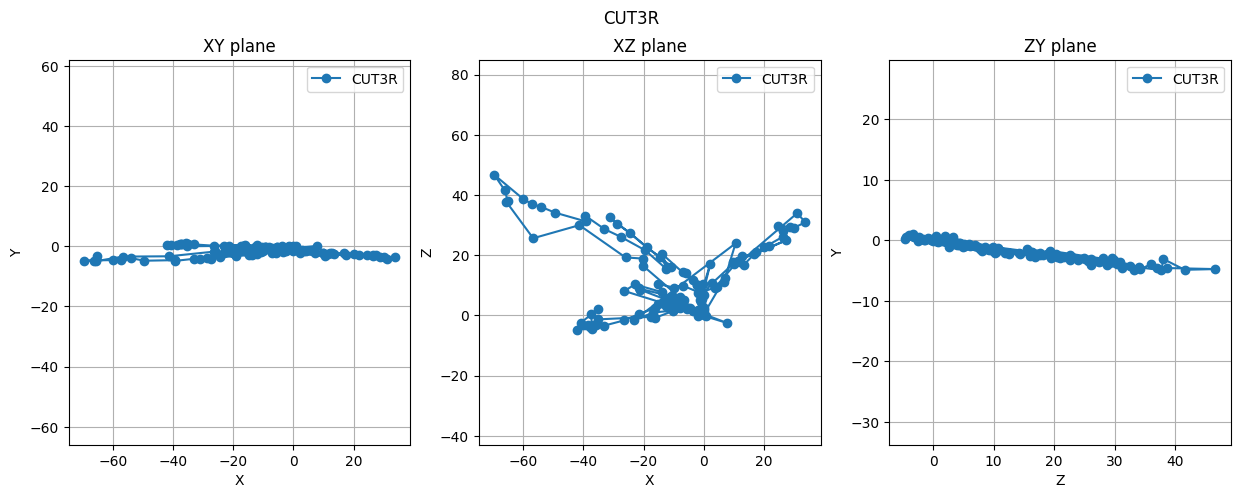

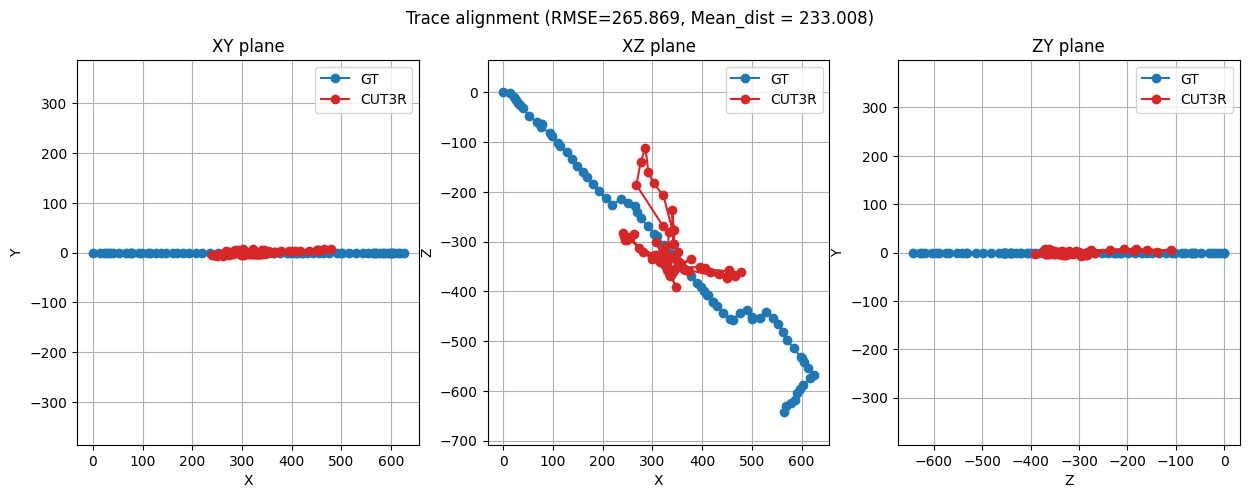

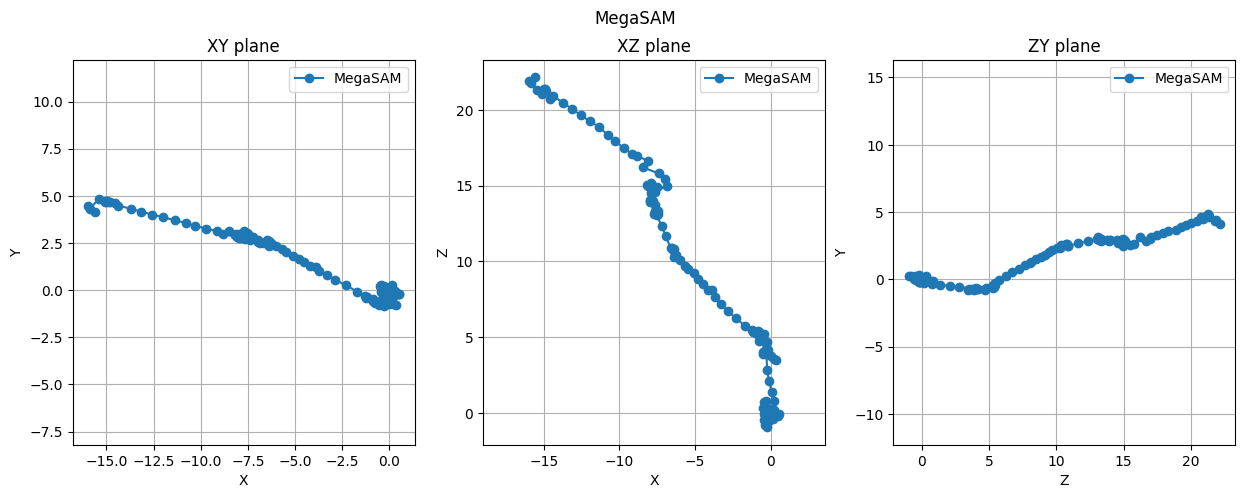

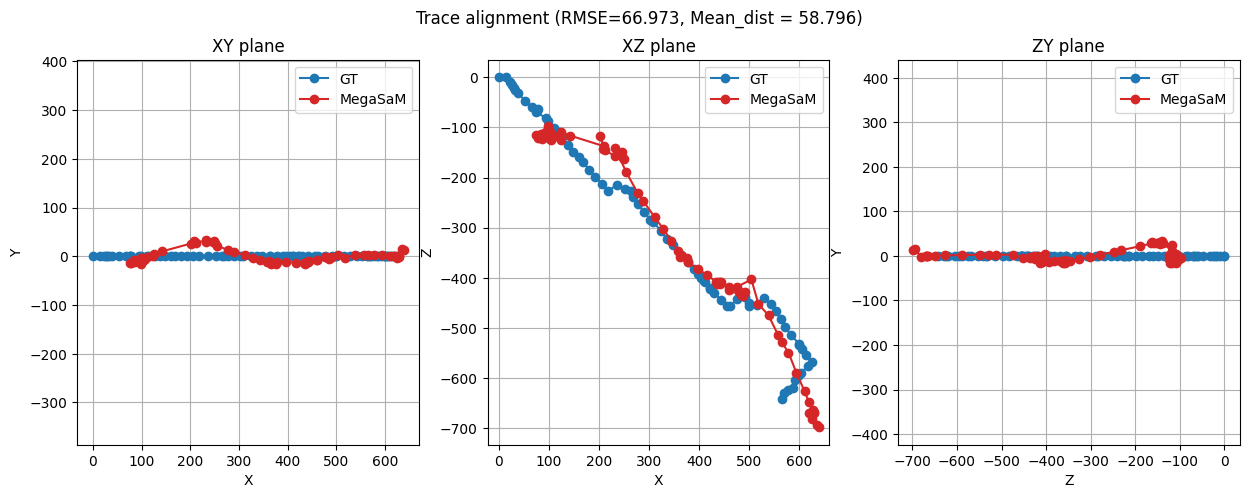

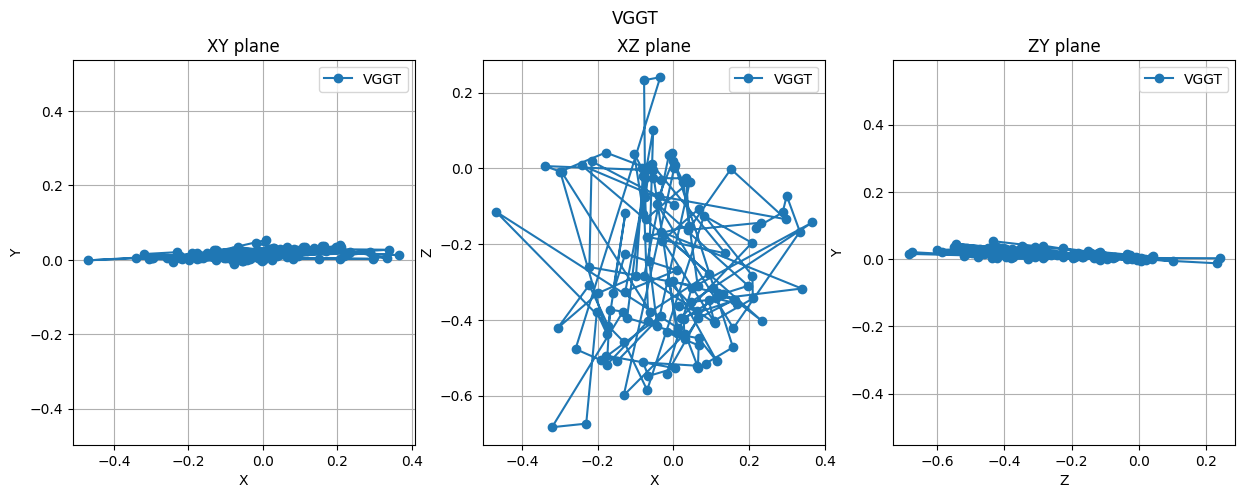

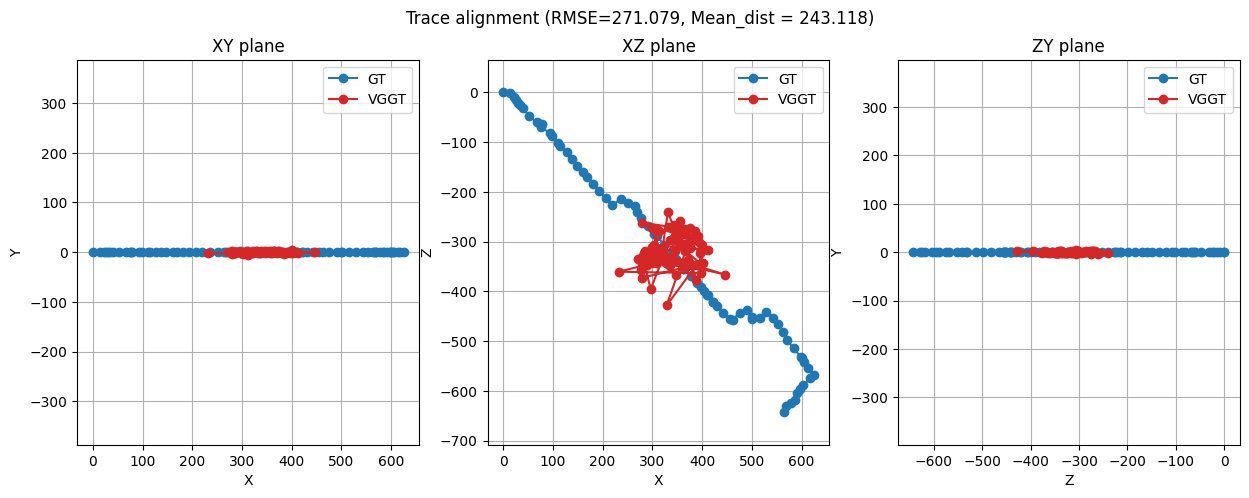

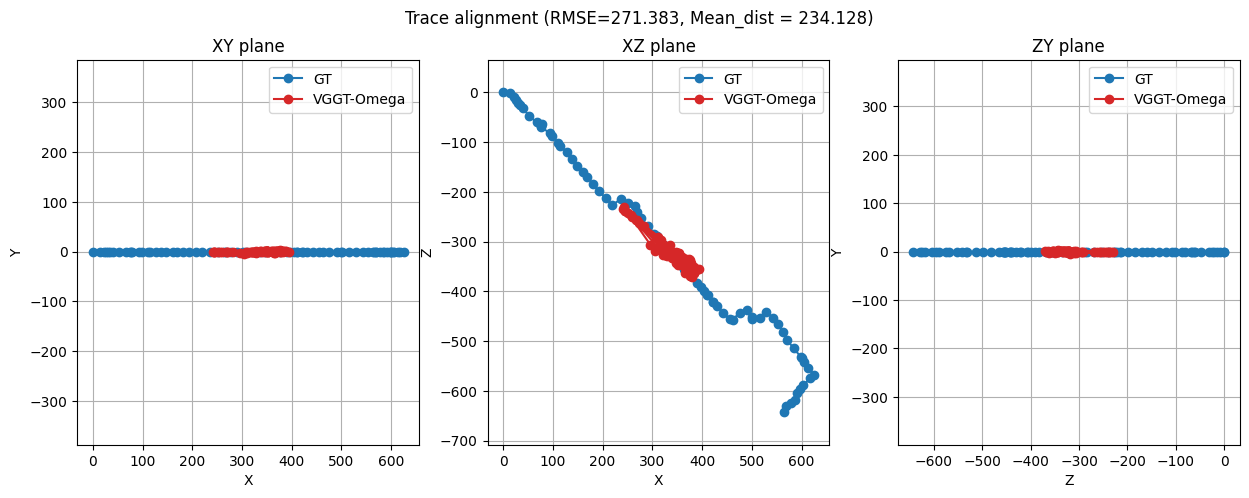

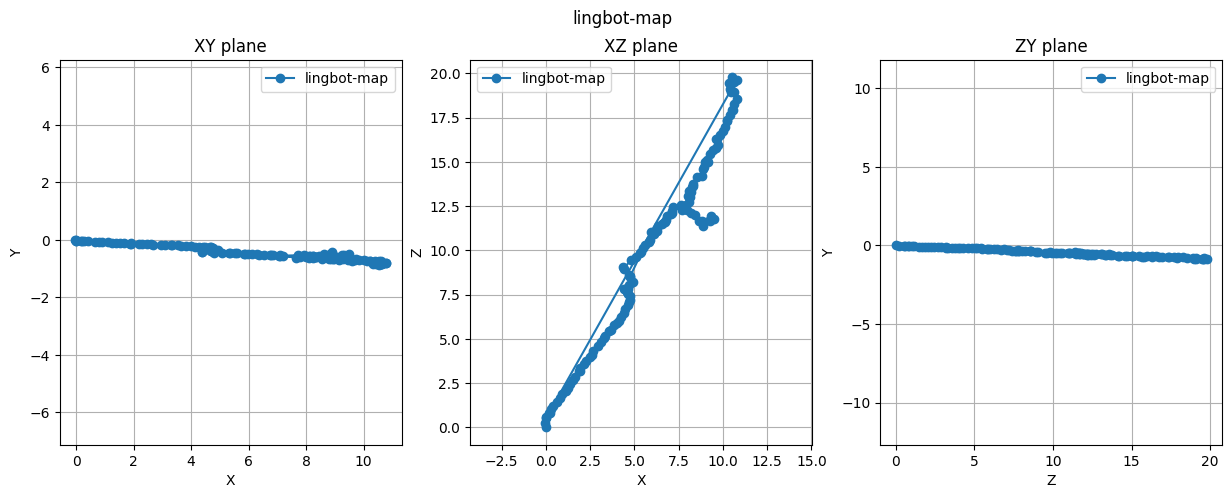

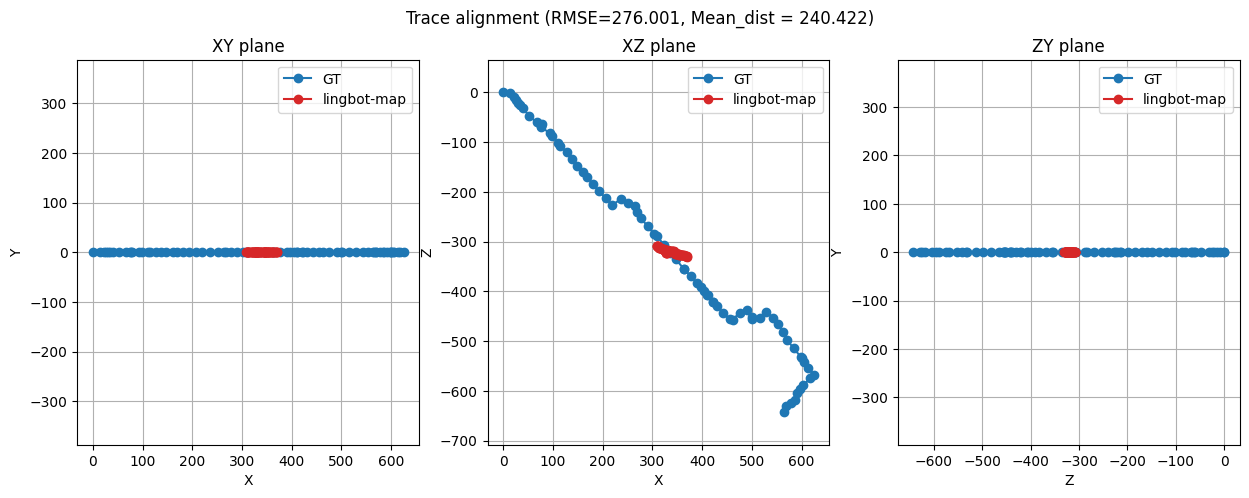

In [12]:
from Thr3D.F_post_recon_processing import (
    Reconstruction, load_cut3r_trace_v2, load_megasam_trace, load_VGGT_trace,
    load_lingbot_map_trace, positions_to_frame_dict,
)
from Q_Metric_georeferencing import GPS_camerapose_matcher
from Thr3D.G_transforms_alignments import umeyama_align


def trajectory_length(positions):
    """Path length -- distance actually travelled, sensitive to drift accumulation."""
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))


def spatial_extent(positions):
    """Radius of gyration of the camera positions. NOT a reliable reconstruction-
    difficulty proxy on its own -- falsifiable by counterexample: walking straight
    at a subject gives LARGE extent (positions spread over a line) but WORSE
    reconstruction (near-collinear viewpoints, little angular/parallax diversity
    relative to the subject -- a classic degenerate SfM baseline configuration);
    orbiting the same subject at a fixed radius gives MODERATE extent but usually
    BETTER reconstruction (maximal angular diversity, many viewpoints converging
    on the same structure). What actually matters is angular coverage relative to
    scene content, which isn't computable from camera positions alone -- it needs
    to know where the scene content is. Reported as honest context, not as a
    trustworthy difficulty signal -- don't infer "harder" or "easier" from this
    number alone."""
    centroid = positions.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((positions - centroid) ** 2, axis=1))))


def align_and_score(technique, world_pos_dict, runtime_minutes):
    GPS_locs, lat_0, lon_0, object_locs = GPS_camerapose_matcher(GPS_dict, world_pos_dict)
    R, s, t, B_aligned, rmse = umeyama_align(
        GPS_locs, object_locs, label_A="GT", label_B=technique,
        out_path=out_dir / f"{case_name}_{experiment}_{technique}_align.png",
       
    )
    mean_dist = float(np.mean(np.linalg.norm(GPS_locs - B_aligned, axis=1)))
    traj_len = trajectory_length(GPS_locs)
    return {
        # --- primary, trustworthy stats -- everything below this line is
        # context/normalization attempts for cross-video comparison, not to be
        # taken as more authoritative than these two raw numbers ---
        "technique": technique,
        "rmse": rmse,
        "mean_dist": mean_dist,
        "n_points": len(GPS_locs),
        # --- secondary context: attempts to make traces comparable across
        # videos of different length/shape. Two position-only normalizations
        # were tried and both have known failure modes (see docstrings above).
        # The theoretically correct difficulty measure is angular diversity
        # (triangulation angle) or observation count PER RECONSTRUCTED 3D POINT,
        # not per camera position -- but that needs per-point visibility/
        # correspondence data across frames, a much heavier computation this
        # notebook doesn't currently do. Reported for context, not as ranking
        # criteria. ---
        "trajectory_length": traj_len,
        "spatial_extent": spatial_extent(GPS_locs),
        "rmse_cm_per_m": 100 * rmse / traj_len if traj_len > 0 else float("nan"),
        "runtime_minutes": runtime_minutes,
    }


results = []

if FLAGS["CUT3R_RECON"]:
    _, world_pos_dict = load_cut3r_trace_v2(cut3r_output_dir() / "camera")
    results.append(align_and_score("CUT3R", world_pos_dict, runtimes.get("CUT3R")))

if FLAGS["MEGA_SAM_RECON"]:
    megasam_output_dir = case_dir() / "036_MEGASAM_output" / experiment
    megasam_npz_path =  megasam_output_dir/ f"{asset_name()}_sgd_cvd_hr.npz"
    print(megasam_npz_path)
    positions,_ = load_megasam_trace(megasam_npz_path, frames_dir = frames_for_recon)
    print(frames_for_recon)

    world_pos_dict = positions_to_frame_dict(positions, frames_for_recon, FRAME_NAME_FMT)
    results.append(align_and_score("MegaSaM", world_pos_dict, runtimes.get("MegaSaM")))

if FLAGS["VGGT_RECON"]:
    positions , _ = load_VGGT_trace(vggt_output_dir(), frames_for_recon)
    world_pos_dict = positions_to_frame_dict(positions, frames_for_recon, FRAME_NAME_FMT)
    results.append(align_and_score("VGGT", world_pos_dict, runtimes.get("VGGT")))

if FLAGS["VGGT_O_RECON"]:
    recon = Reconstruction.load(frames_for_recon, predictions_path(), FRAME_NAME_FMT)
    world_pos_dict = recon.cam_pos_dict()
    results.append(align_and_score("VGGT-Omega", world_pos_dict, runtimes.get("VGGT-Omega")))

if FLAGS["LINGBOT_MAP_RECON"]:
    _, world_pos_dict = load_lingbot_map_trace(lingbot_map_dir())
    results.append(align_and_score("lingbot-map", world_pos_dict, runtimes.get("lingbot-map")))

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)  # raw RMSE, the pure stat -- not a normalized/fudged one
results_df

## Combined across videos

Re-run this whole notebook per video, appending each run's `results_df` to a growing CSV, then summarize here. Raw `rmse` is the pure stat; `rmse_cm_per_m` is shown alongside as a secondary, imperfect attempt at cross-video comparability (see the batch-comparison cell's caveats -- it's not a validated difficulty measure, just the least-bad normalization tried so far). With very few videos this is just an average of 1-2 numbers -- not meaningful yet on its own, but the aggregation is correct and ready to use once more videos accumulate. Once there are enough videos (~6+), consider average-rank-per-video instead of raw-mean (scale-invariant across videos of differing difficulty), and Friedman+Nemenyi if a statistical-significance comparison between techniques is needed -- plain Wilcoxon is pairwise-only and wants more paired samples (videos) than we'll have for a while to mean much.

In [ ]:
all_results_path = out_dir / "all_videos_results.csv"

combined = results_df.copy()
combined.insert(0, "case_name", case_name)
combined.insert(1, "experiment", experiment)

if all_results_path.exists():
    combined = pd.concat([pd.read_csv(all_results_path), combined], ignore_index=True)
combined.to_csv(all_results_path, index=False)

# raw rmse first (the pure stat), rmse_cm_per_m alongside as the (imperfect,
# see spatial_extent's docstring) attempt at cross-video comparability -- averaging
# raw rmse across videos of very different length/difficulty has its own distortion,
# so both are shown rather than picking one as definitively "the" combined number.
combined.groupby("technique")[["rmse", "rmse_cm_per_m"]].agg(["mean", "median", "count"])